# Notebook 3 – Radar QoD, the Lyapunov Queue, and LyQoD vs. P2 

__LyQoD general simulator__ 


## 2-0. Setup

In [1]:
import sys, pathlib 
REPO_ROOT = pathlib.Path.cwd().parent
if str(REPO_ROOT) not in sys.path: 
    sys.path.insert(0, str(REPO_ROOT)) 

import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import linprog 

%matplotlib inline 
plt.rcParams["figure.dpi"] = 100 
RNG = np.random.default_rng(0) 

## 2-1. The 1-bit ADC radar model and QSCNR 

The radar quantized receiver quantizes target + clutter + noise with 1-bit ADCs. 
After a unit-norm receive filter $u$, the resulting statistic is asymptotically Gaussian
and the quantized SCNR is: 
$$ \begin{equation} 
    \mathrm{QSCNR}(\tilde{x}, u) = \frac{2}{\pi} \cdot \frac{
        \mathrm{SNR}_{R} \left|u^HG_0x\right|^{2}}{
        \sum_{q}\mathrm{CNR}_{q} \left|u^HG_qx\right|^{2} + \|u\|^2
        }
    = \frac{2}{\pi} \mathrm{SCNR}_{\infty}, 
\end{equation}$$ 

The $2\pi\approx -1.96$dB being the fixed 1-bit-ADC penalty relative to the unquantized reference $\mathrm{SCNR}_{\infty}$. Detection probability at fixed false-alarm rate $\Pr_{FA}$: 
$$ \begin{equation} 
    \Pr_{D} = \exp \left( \frac{\ln \Pr_{FA}}{1 + \mathrm{QSCNR}} \right)
\end{equation}$$
strictly increasing in QSCNR – so the -1.96dB quantization penalty is real, visible cost in detection probability, not a scale factor. 

SCNR_inf = 0.4651, QSCNR = 0.2961  (ratio = 0.6366 = 2/pi = 0.6366)


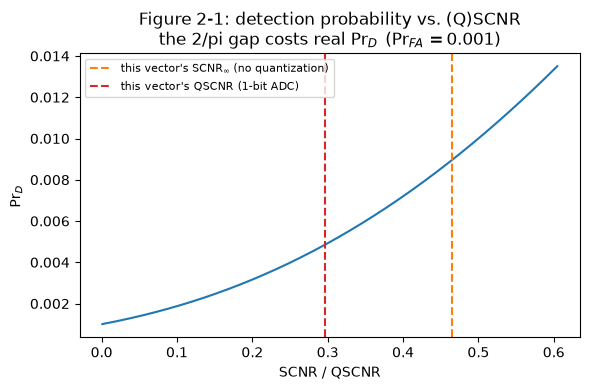

In [2]:
def ula_steering(theta_rad, N):
    n = np.arange(N)
    return np.exp(1j * np.pi * n * np.sin(theta_rad))

def steering_matrix(theta_rad, Nt, Nr, scale):
    a, b = ula_steering(theta_rad, Nr), ula_steering(theta_rad, Nt)
    return scale * np.outer(a, np.conj(b))

def geometry_scale(E, Nt, Nr):
    return np.sqrt(E / (2.0 * Nt)) / np.sqrt(Nr * Nt)

def scnr_inf(x_c, u, G0, Gq, SNR_R, CNR_lin):
    target = np.conj(u) @ (G0 @ x_c)
    num = SNR_R * np.abs(target) ** 2
    den = np.linalg.norm(u) ** 2
    for q, Gqq in enumerate(Gq):
        den += CNR_lin[q] * np.abs(np.conj(u) @ (Gqq @ x_c)) ** 2
    return num / den

def qscnr(x_c, u, G0, Gq, SNR_R, CNR_lin):
    return (2.0 / np.pi) * scnr_inf(x_c, u, G0, Gq, SNR_R, CNR_lin)

def pr_d(Pr_FA, q):
    return np.exp(np.log(Pr_FA) / (1.0 + q))

# toy geometry
Nt, Nr, Q = 16, 16, 1
E, SNR_R_db, CNR_db, Pr_FA = 1.0, 15.0, 30.0, 1e-3
SNR_R, CNR_lin = 10 ** (SNR_R_db / 10), np.array([10 ** (CNR_db / 10)])
scale = geometry_scale(E, Nt, Nr)
G0 = steering_matrix(np.deg2rad(10.0), Nt, Nr, scale)
Gq = [steering_matrix(np.deg2rad(-30.0), Nt, Nr, scale)]

x_tilde = RNG.choice([-1.0, 1.0], size=2 * Nt)
x_c = x_tilde[:Nt] + 1j * x_tilde[Nt:]
u = np.ones(Nr) / np.sqrt(Nr)   # arbitrary unit-norm filter, just to get a number

s_inf = scnr_inf(x_c, u, G0, Gq, SNR_R, CNR_lin)
q_val = qscnr(x_c, u, G0, Gq, SNR_R, CNR_lin)
print(f"SCNR_inf = {s_inf:.4g}, QSCNR = {q_val:.4g}  (ratio = {q_val/s_inf:.4g} = 2/pi = {2/np.pi:.4g})")

grid = np.linspace(1e-3, max(s_inf, q_val) * 1.3, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(grid, pr_d(Pr_FA, grid), lw=1.5)
ax.axvline(s_inf, color="C1", ls="--", label=r"this vector's $\mathrm{SCNR}_\infty$ (no quantization)")
ax.axvline(q_val, color="C3", ls="--", label=r"this vector's QSCNR (1-bit ADC)")
ax.set_xlabel("SCNR / QSCNR"); ax.set_ylabel(r"$\Pr_D$")
ax.set_title(f"Figure 2-1: detection probability vs. (Q)SCNR\nthe 2/pi gap costs real $\\Pr_D$ ($\\Pr_{{FA}}={Pr_FA:g}$)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2-2. The MM surrogate and the fused per-slot LP 

For fixed $\tilde{x}$, the radar receive filter maximzing the QSCNR is closed form: 
$$\begin{equation}
    u^{\star} \propto B^{-1}G_0 x, \quad B = \sum_{q} \mathrm{CNR}_{q} (G_qx)(G_qx)^H + I. 
\end{equation}$$ 
Writing $\mathrm{QSCNR} = \frac{2}{\pi} a(x) / b (x) $, MM minorizes it around the current iterate $x_k$ by a linear term with surrogate gradient: 
$$\begin{equation}
    w_k = \frac{2}{\pi} \cdot \frac{b_k (Px_k) - a_k (Qx_k)}{b_k^2}, \quad P=G_0^Huu^HG_0, \; Q = \sum_q \mathrm{CNR}_{q} G_q^Huu^HG_q. 
\end{equation}$$ 
Substituded into the drift-plus-penalty objective, one __LP per MM iteration__ fuses the comm amrgin and the (linearized) radar reward: 
$$\begin{equation}
    \max_{\tilde{x} \in [-1, 1]^{2N_T}, \mu \ge 0} V \mu + Z \tilde{w}_{k}^{T} \tilde{x} \qquad \text{s.t.} \qquad A_C \tilde{x} \ge \mu \mathbf{1}. 
\end{equation}$$ 
Alternating (receive filter) -> (surrogate) --> (LP) --> (greedy round) is guaranteed to make QSCNR non-decreasing.

[0.06511666508816571, 0.25241259738616434, 1.150048216422737, 4.247141850489354, 7.756350712315854, 8.92007630324906, 8.271860582646868]


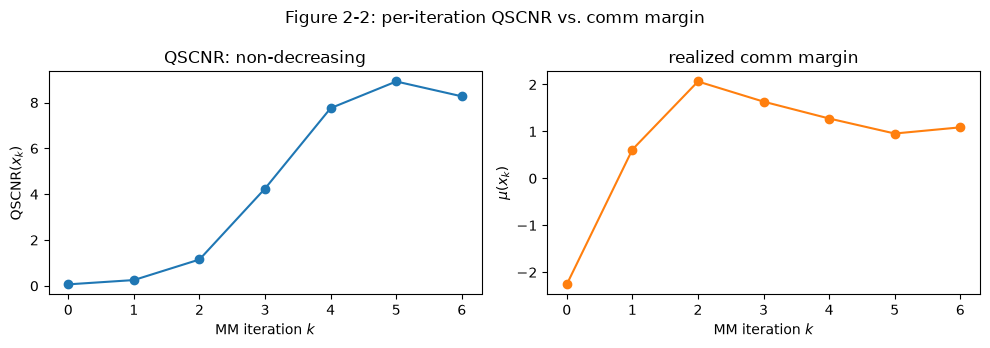

In [26]:
def receive_filter(x_c, G0, Gq, CNR_lin, Nr):
    B = np.eye(Nr, dtype=complex) 
    for q, Gqq in enumerate(Gq): 
        gqx = Gqq @ x_c 
        B += CNR_lin[q] * np.outer(gqx, np.conj(gqx)) 
    u_raw = np.linalg.solve(B, G0 @ x_c) 
    return u_raw / np.linalg.norm(u_raw) 

def mm_surrogate(x_c, G0, Gq, SNR_R, CNR_lin, Nt): 
    u = receive_filter(x_c, G0, Gq, CNR_lin, Nr)
    uuH = np.outer(u, u.conj()) 
    P = SNR_R * (G0.conj().T @ uuH @ G0) 
    Qm = np.zeros((Nt, Nt), dtype=complex) 
    for q, Gqq in enumerate(Gq): 
        Qm += CNR_lin[q] * (Gqq.conj().T @ uuH @ Gqq) 
        a_k = float(np.real(x_c.conj() @ P @ x_c)) 
        b_k = float(np.real(x_c.conj() @ Qm @ x_c)) + float(np.linalg.norm(u) ** 2) 
        w = (2.0 / np.pi) * (b_k * (P @ x_c) - a_k * (Qm @ x_c)) / b_k ** 2 
        w_t = np.concatenate([w.real, w.imag]) 
        return w_t, (2.0 / np.pi) * a_k / b_k, u 

def solve_fused_LP(A, w_t, Z, V): 
    n_rows, n = A.shape 
    c = -np.concatenate([Z * w_t, [V]])     
    A_ub = np.hstack([-A, np.ones((n_rows, 1))]) 
    b_ub = np.zeros(n_rows) 
    bounds = [(-1.0, 1.0)] * n + [(0.0, None)]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs') 
    return res.x[:n], float(res.x[n]), res.success 

def sign_project(v): 
    return np.where(v >= 0.0, 1.0, -1.0) 

def greedy_round_fused(x_frac, A, w_t, Z, V, eps=1e-6): 
    x = sign_project(x_frac) 
    idx = np.where(np.abs(x_frac) < 1 - eps) 
    def score(c): 
        return V * float(np.min(A @ c)) + Z * float(w_t @ c) 
    for i in idx: 
        best, best_s = x, score(x) 
        for v in (-1.0, 1.0): 
            cand = x.copy(); cand[i] = v 
            s = score(cand) 
            if s > best_s: 
                best, best_s = cand, s 
        x = best 
    return x 


def draw_psk_symbols(K, M, rng): 
    k = rng.integers(0, M, size=K) 
    return np.exp(1j * 2.0 * np.pi * K / M) 

def margin_constraints_psk(bar_h, M): 
    Nt, K = bar_h.shape 
    t = np.tan(np.pi / M) 
    rows = np.empty((2 * K, 2 * Nt)) 
    for uu in range(K): 
        h_re, h_im = bar_h[:, uu].real, bar_h[:, uu].imag 
        rows[2 * uu] = np.concatenate([t * h_re + h_im, t * h_im - h_re]) 
        rows[2 * uu + 1] = np.concatenate([t * h_re - h_im, t * h_im + h_re]) 
    return rows 

M, K = 8, 3 
H = (RNG.standard_normal((Nt, K)) + 1j * RNG.standard_normal((Nt, K))) / np.sqrt(2.0) 
s = draw_psk_symbols(K, M, RNG) 
bar_h = H * np.exp(1j * np.angle(s)) 
A_C = margin_constraints_psk(bar_h, M) 

V, Z, K_MM = 5.0, 2.0, 8 
x = sign_project(np.concatenate([np.sum(bar_h, axis=1).real, np.sum(bar_h, axis=1).imag]))
q_trace, mu_trace = [], []
for k in range(K_MM): 
    x_c = x[:Nt] + 1j * x[Nt:] 
    w_t, q_k, u = mm_surrogate(x_c, G0, Gq, SNR_R, CNR_lin, Nt) 
    q_trace.append(q_k) 
    mu_trace.append(float(np.min(A_C @ x)))
    x_frac, mu_lp, ok = solve_fused_LP(A_C, w_t, Z, V) 
    x_new = greedy_round_fused(x_frac, A_C, w_t, Z, V) 
    if np.array_equal(x_new, x): 
        break 
    x = x_new 

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5)) 
axes[0].plot(q_trace, "o-"); print(q_trace)
axes[0].set_xlabel("MM iteration $k$"); axes[0].set_ylabel(r"$\operatorname{QSCNR}(x_k)$")
axes[0].set_title("QSCNR: non-decreasing") 
axes[1].plot(mu_trace, "o-", color="C1")
axes[1].set_xlabel("MM iteration $k$"); axes[1].set_ylabel(r"$\mu(x_k)$") 
axes[1].set_title(f"realized comm margin") 
fig.suptitle("Figure 2-2: per-iteration QSCNR vs. comm margin")
plt.tight_layout(); plt.show()


## 2-3. The Lyapunov virtual queue and the DPP master loop 

The radar floor is relaxed from every slot to a long-term average $\bar{g} \ge \Gamma$ via a virtual queue: 
$$\begin{equation}
    Z(t+1) = [Z(t) + \Gamma - \mathrm{QSCNR}(\tilde{x}(t), u(t); t)]^{+}, \quad Z(0) = 0 
\end{equation}$$ 
Z(t) swell on slots that underspend the floor and drains on slots that overspend it. 


Text(0.5, 0.98, 'Figure 2-3: LyQod Toy run')

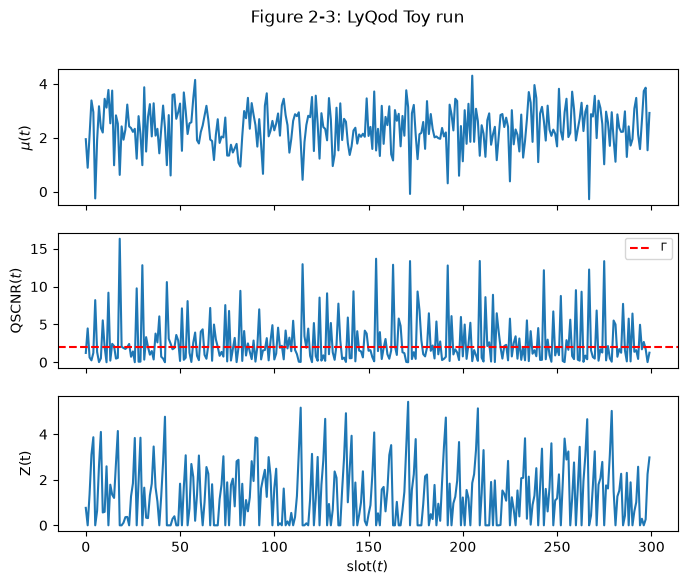

In [30]:
def run_toy_lyqod(T, V, Gamma, sector_deg, clutter_deg, Nt, Nr, K, M, Q, SNR_R, CNR_lin, seed, K_MM=8, scene="iid"): 
    rng = np.random.default_rng(seed) 
    scale = geometry_scale(1.0, Nt, Nr) 
    Z = 0.0 
    mu_hist, q_hist, Z_hist = [], [], [] 
    for t in range(T): 
        H = (rng.standard_normal((Nt, K)) + 1j * rng.standard_normal((Nt, K))) / np.sqrt(2.0) 
        s = draw_psk_symbols(K, M, rng) 
        bar_h = H * np.exp(1j * np.angle(s)) 
        A = margin_constraints_psk(bar_h, M) 
        if scene=="sweep": 
            theta0 = np.deg2rad(-30.0 + (t / (T - 1)) * 60.0) 
            G0 = steering_matrix(theta0, Nt, Nr, scale) 
            Gq = [steering_matrix(np.deg2rad(0.0), Nt, Nr, scale)] * Q 
        else: 
            theta0 = rng.uniform(*np.deg2rad(sector_deg)) 
            phis = rng.uniform(*np.deg2rad(sector_deg), size=Q) 
            G0 = steering_matrix(theta0, Nt, Nr, scale) 
            Gq = [steering_matrix(p, Nt, Nr, scale) for p in phis] 
        
        x = sign_project(np.concatenate([np.sum(bar_h, axis=1). real, np.sum(bar_h, axis=1).imag]))
        for k in range(K_MM): 
            x_c = x[:Nt] + 1j * x[Nt: ]
            w_t, _q, _u = mm_surrogate(x_c, G0, Gq, SNR_R, CNR_lin, Nt) 
            x_frac, _mu, ok = solve_fused_LP(A, w_t, Z, V) 
            x_new = greedy_round_fused(x_frac, A, w_t, Z, V) 
            if np.array_equal(x_new, x):
                break 
            x = x_new 

        x_c = x[:Nt] + 1j * x[Nt:] 
        u = receive_filter(x_c, G0, Gq, CNR_lin, Nr) 
        g = qscnr(x_c, u, G0, Gq, SNR_R, CNR_lin) 
        mu = float(np.min(A @ x)) 
        Z = max(0.0, Z + Gamma - g) 
        mu_hist.append(mu); q_hist.append(g); Z_hist.append(Z) 
    return np.array(mu_hist), np.array(q_hist), np.array(Z_hist) 

T, V, Gamma = 300, 8.0, 2.0 
mu_h, q_h, Z_h = run_toy_lyqod(T, V, Gamma, (-60, 60), None, 
                               Nt=16, Nr=16, K=3, M=8, Q=1, 
                               SNR_R=SNR_R, CNR_lin=CNR_lin, seed=7)

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axes[0].plot(mu_h); axes[0].set_ylabel(r"$\mu(t)$") 
axes[1].plot(q_h); axes[1].axhline(Gamma, color="red", ls="--", label=r"$\Gamma$"); axes[1].set_ylabel("QSCNR$(t)$"); axes[1].legend(fontsize=8) 
axes[2].plot(Z_h); axes[2].set_ylabel("Z(t)"); axes[2].set_xlabel("slot$(t)$") 
fig.suptitle("Figure 2-3: LyQod Toy run")
        

## 2-4. P2 (per-slot floor) vs. LyQoD (long-term floor): the feasibility rescue 

P2 (1bitISAC's baseline) enforces $\mathrm{QSCNR} \ge \Gamma$ on every slot: it first "warms up" toward the max-achievable QSCNR by repeatedly setting $x = sign(w)$, then solves a comm-margin LP subject to the linearized floor. If even the best achievable QSCNR misses $\Gamma$, the __slot is dropped__. 
LyQoD never drops a slot (its radar term is a reward, not a constraint) – it just spends more or less queue weighted attention on radar depending on $Z(t)$. 

To see the difference, use a `sweep` scene: the target angle ramps linearly across the clutter angle, creating geometry so poor near the crossing that P2's per-slot floor becomes infeasible there, while LyQoD's queue absorb it. 

In [ ]:
def radar_warmstart(bar_h_dir, G0, Gq, SNR_R, CNR_lin, Nt, max_iter=30): 
    x = sign_project(bar_h_dir) 
    q_prev = -np.inf 
    for _ in range(max_iter): 
        x_c = x[:Nt] + 1j * x[Nt:] 
        w_t, q, _u = mm_surrogate(x_c, G0, Gq, SNR_R, CNR_lin, Nt) 
        if q < q_prev + 1e-12: 
            break 
        q_prev = q 
        x_new = sign_project(w_t)
        if np.array_equal(x_new, x): 
            break 
        x = x_new 
    return x, q_prev 
